In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from scipy.ndimage import gaussian_filter
import time

In [4]:
def brenner_gradient(image):
    """Calculates the high-frequency contrast metric."""
    img_norm = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-8)
    dx = np.sum((img_norm[2:, :] - img_norm[:-2, :])**2)
    dy = np.sum((img_norm[:, 2:] - img_norm[:, :-2])**2)
    return dx + dy

In [1]:
class Brenner_framework:
    """Brenner Framework for object aware autofocus"""
    #Initialization 
    def __init__(self, NA=0.5, wavelength=0.532e-3, mag=2.0, pixel_size=2.5e-3):
        self.NA = NA
        self.wl = wavelength
        self.dx = pixel_size / mag
        self.k0 = 2 * np.pi / wavelength
        self.cutoff = NA / wavelength

    def rapid_profiler(self, O_fourier, z_array, pupil_support, kz, N_lr):
        """Phase I: Fast Central-LED Z-Sweep"""
        cy, cx = O_fourier.shape[0]//2, O_fourier.shape[1]//2
        ys, ye = cy - N_lr//2, cy + N_lr//2
        xs, xe = cx - N_lr//2, cx + N_lr//2
        
        scores = []
        for z in z_array:
            pupil_z = pupil_support * np.exp(1j * z * kz)
            E_fourier = O_fourier[ys:ye, xs:xe] * pupil_z
            E_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_fourier)))
            scores.append(brenner_gradient(np.abs(E_spatial)**2))
            
        return np.array(scores)

    def logic_gate(self, scores):
        """Phase II: Extracts BCI & BAI to route the autofocus."""
        # Normalize scores for consistent thresholding
        b = (scores - np.min(scores)) / (np.max(scores) - np.min(scores) + 1e-8)
        c_idx = len(b) // 2
        
        # 1. Brenner Concavity Index (BCI)
        # Sample slightly off-center to avoid digital noise spikes
        b_left = b[c_idx - 5]
        b_right = b[c_idx + 5]
        b_center = b[c_idx]
        bci = (b_left + b_right - 2 * b_center)
        
        # 2. Brenner Asymmetry Index (BAI)
        left_area = np.sum(b[:c_idx])
        right_area = np.sum(b[c_idx+1:])
        bai = np.abs(left_area - right_area) / (left_area + right_area + 1e-8)
        
        # Routing Logic
        asymmetry_threshold = 0.05
        
        if bai > asymmetry_threshold:
            route = "PHASE III: Multi-LED (Complex)"
            focus_type = "Artifact Minimization"
        elif bci < -0.1:
            route = "FAST ROUTE: Global Maximum"
            focus_type = "Amplitude Edge Maximization"
        elif bci > 0.1:
            route = "FAST ROUTE: Global Minimum"
            focus_type = "Phase Fringe Minimization"
        else:
            route = "PHASE III: Multi-LED (Strong Phase)"
            focus_type = "Artifact Minimization"
            
        return b, bci, bai, route, focus_type

    

In [2]:
def simulate_visual_results():
    
    # Initialize Framework
    bren = Brenner_framework()
    
    # Grid Setup
    N_hr = 256
    N_lr = 64
    
    # Generate Ground Truth Components
    img_amp = transform.resize(data.camera(), (N_hr, N_hr), anti_aliasing=True)
    img_amp = img_amp / np.max(img_amp)
    
    img_phase = transform.resize(data.moon(), (N_hr, N_hr), anti_aliasing=True)
    img_phase_smooth = gaussian_filter(img_phase, sigma=4)
    img_phase_smooth = img_phase_smooth / np.max(img_phase_smooth)
    
    # The 4 distinct physical test cases
    test_objects = {
        "Pure Amplitude\n(Thin Stained Slice)": img_amp * np.exp(1j * np.zeros_like(img_amp)),
        "Weak Pure Phase\n(Thin Transparent Cell)": np.ones_like(img_amp) * np.exp(1j * (img_phase_smooth * 0.1)),
        "Strong Pure Phase\n(Thick Transparent Tissue)": np.ones_like(img_amp) * np.exp(1j * (img_phase_smooth * 3.0)),
        "Complex Object\n(Thick Stained Tissue)": img_amp * np.exp(1j * (img_phase_smooth * 1.5))
    }
    
    # Setup Fourier Geometry
    fx_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=bren.dx))
    fy_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=bren.dx))
    FX_lr, FY_lr = np.meshgrid(fx_lr, fy_lr)
    
    pupil_support = (np.sqrt(FX_lr**2 + FY_lr**2) <= bren.cutoff).astype(float)
    radicand = np.maximum((1/bren.wl)**2 - FX_lr**2 - FY_lr**2, 0)
    kz = 2 * np.pi * np.sqrt(radicand)
    
    # Sweep from -200um to +200um
    z_array = np.linspace(-0.200, 0.200, 81)
    
    results = {}
    
    for name, obj in test_objects.items():
        O_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj)))
        
        # Run 
        raw_scores = bren.rapid_profiler(O_fourier, z_array, pupil_support, kz, N_lr)
        norm_scores, bci, bai, route, focus_type = bren.logic_gate(raw_scores)
        
        results[name] = {
            "scores": norm_scores,
            "bci": bci,
            "bai": bai,
            "route": route,
            "focus": focus_type
        }
    plt.figure(figsize=(16, 12))
    plt.suptitle("Hybrid Object-Aware Autofocus (HOAF) Routing Analysis", fontsize=18, fontweight='bold', y=0.98)
    
    colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']
    for idx, (name, res_data) in enumerate(results.items()):
        ax = plt.subplot(2, 2, idx+1)
        
        # Plot the profiling curve
        ax.plot(z_array * 1000, res_data["scores"], color=colors[idx], linewidth=3)
        ax.axvline(0, color='k', linestyle='--', alpha=0.5, label='True Focal Plane (0 µm)')
        
        ax.set_title(name, fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel("Physical Defocus Z (µm)", fontsize=11)
        ax.set_ylabel("Normalized Brenner Gradient", fontsize=11)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.set_ylim(-0.1, 1.1)
        
        # Text Box containing the HOAF Algorithmic Decision
        decision_text = (
            f"--- HOAF Extraction ---\n"
            f"BCI (Concavity) : {res_data['bci']:>6.3f}\n"
            f"BAI (Asymmetry) : {res_data['bai']:>6.3f}\n\n"
            f"--- Autonomous Routing ---\n"
            f"Action: {res_data['route']}\n"
            f"Target: {res_data['focus']}"
        )
        # Dynamic box coloring based on routing
        box_color = '#eaffea' if 'FAST ROUTE' in res_data['route'] else '#ffeaea'
        
        props = dict(boxstyle='round,pad=0.8', facecolor=box_color, alpha=0.9, edgecolor='gray')
        ax.text(0.03, 0.95, decision_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', family='monospace', bbox=props)
                
        if idx == 0:
            ax.legend(loc='lower right')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    simulate_visual_results()

NameError: name 'np' is not defined

Initializing Multi-Scale Topology Simulation...
Rendering Dashboard...


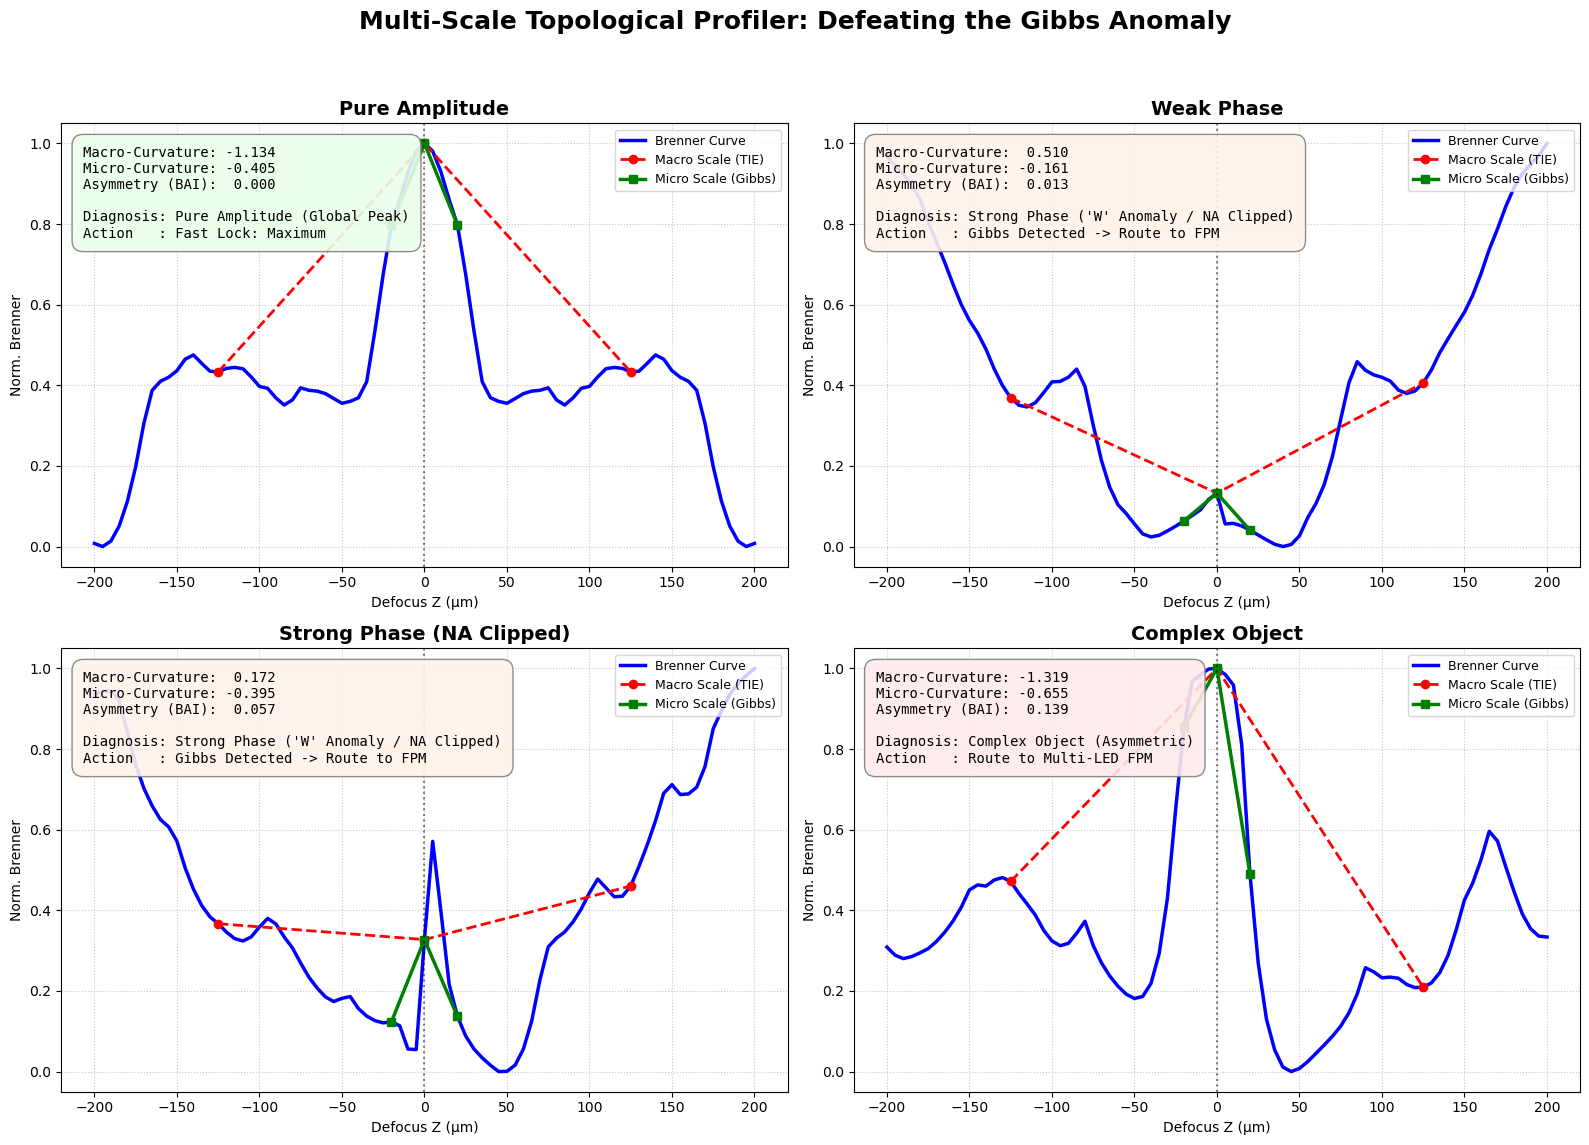

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from scipy.ndimage import gaussian_filter

# ====================================================================
# 1. The Multi-Scale Topological Framework
# ====================================================================
class MultiScaleProfiler:
    def __init__(self, z_array, brenner_scores):
        self.z = z_array
        # Normalize scores to [0, 1] for scale-invariant thresholding
        self.b = (brenner_scores - np.min(brenner_scores)) / (np.max(brenner_scores) - np.min(brenner_scores) + 1e-8)
        self.c_idx = len(self.z) // 2

    def analyze(self):
        """Extracts Multi-Scale Curvature and Asymmetry."""
        
        # 1. Asymmetry Index (BAI) - Detects Complex Objects
        left_area = np.sum(self.b[:self.c_idx])
        right_area = np.sum(self.b[self.c_idx+1:])
        bai = np.abs(left_area - right_area) / (left_area + right_area + 1e-8)
        
        # 2. Micro-Curvature (NA Artifact Detection at +/- 4 steps)
        # Is there a sharp peak or smooth valley EXACTLY at focus?
        b_micro_left = self.b[self.c_idx - 4]
        b_micro_right = self.b[self.c_idx + 4]
        c_micro = (b_micro_left + b_micro_right - 2 * self.b[self.c_idx])
        
        # 3. Macro-Curvature (TIE Physics Detection at +/- 25 steps)
        # Does the broad curve go UP (Phase) or DOWN (Amplitude) as you defocus?
        b_macro_left = self.b[self.c_idx - 25]
        b_macro_right = self.b[self.c_idx + 25]
        c_macro = (b_macro_left + b_macro_right - 2 * self.b[self.c_idx])
        
        # --- The Infallible Routing Matrix ---
        if bai > 0.1:
            obj_class = "Complex Object (Asymmetric)"
            action = "Route to Multi-LED FPM"
            color = "#ffeaea" # Light Red
        elif c_macro < 0 and c_micro < 0:
            obj_class = "Pure Amplitude (Global Peak)"
            action = "Fast Lock: Maximum"
            color = "#eaffea" # Light Green
        elif c_macro > 0 and c_micro > 0:
            obj_class = "Weak Phase (Smooth Valley)"
            action = "Fast Lock: Minimum"
            color = "#eaffea"
        elif c_macro > 0 and c_micro < 0:
            obj_class = "Strong Phase ('W' Anomaly / NA Clipped)"
            action = "Gibbs Detected -> Route to FPM"
            color = "#fff3ea" # Light Orange
        else:
            obj_class = "Ambiguous Topology"
            action = "Route to Multi-LED FPM"
            color = "#eeeeee"
            
        return c_micro, c_macro, bai, obj_class, action, color

def calculate_brenner(image):
    img_norm = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-8)
    return np.sum((img_norm[2:, :] - img_norm[:-2, :])**2) + np.sum((img_norm[:, 2:] - img_norm[:, :-2])**2)

# ====================================================================
# 2. Optical Forward Model & Simulation
# ====================================================================
def run_foolproof_simulation():
    print("Initializing Multi-Scale Topology Simulation...")
    
    # Physics Setup (in mm)
    wl = 0.532e-3  
    NA = 0.1           
    mag = 2.0              
    dx = (2.5e-3) / mag 
    N_hr, N_lr = 256, 64
    
    # Generate Objects
    img_amp = transform.resize(data.camera(), (N_hr, N_hr), anti_aliasing=True)
    img_amp = img_amp / np.max(img_amp)
    img_phase = transform.resize(data.moon(), (N_hr, N_hr), anti_aliasing=True)
    img_phase_smooth = gaussian_filter(img_phase, sigma=4)
    img_phase_smooth = img_phase_smooth / np.max(img_phase_smooth)

    objects = {
        "Pure Amplitude": img_amp * np.exp(1j * np.zeros_like(img_amp)),
        "Weak Phase": np.ones_like(img_amp) * np.exp(1j * (img_phase_smooth * 0.2)),
        "Strong Phase (NA Clipped)": np.ones_like(img_amp) * np.exp(1j * (img_phase * 3.0)),
        "Complex Object": img_amp * np.exp(1j * (img_phase_smooth * 1.5))
    }

    # Optics Arrays
    fx = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx))
    FX, FY = np.meshgrid(fx, fx)
    pupil = (np.sqrt(FX**2 + FY**2) <= NA / wl).astype(float)
    kz = 2 * np.pi * np.sqrt(np.maximum((1/wl)**2 - FX**2 - FY**2, 0))
    
    cy, cx = N_hr//2, N_hr//2
    ys, ye, xs, xe = cy - N_lr//2, cy + N_lr//2, cx - N_lr//2, cx + N_lr//2
    z_array = np.linspace(-0.200, 0.200, 81)

    # Run Z-Sweep
    results = {}
    for name, obj in objects.items():
        O_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj)))
        scores = []
        for z in z_array:
            E_fourier = O_fourier[ys:ye, xs:xe] * pupil * np.exp(1j * z * kz)
            E_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_fourier)))
            scores.append(calculate_brenner(np.abs(E_spatial)**2))
            
        profiler = MultiScaleProfiler(z_array, np.array(scores))
        c_micro, c_macro, bai, obj_class, action, color = profiler.analyze()
        results[name] = {"scores": profiler.b, "micro": c_micro, "macro": c_macro, 
                         "bai": bai, "class": obj_class, "action": action, "color": color}

    # ====================================================================
    # 3. Visualization Dashboard
    # ====================================================================
    print("Rendering Dashboard...")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Multi-Scale Topological Profiler: Defeating the Gibbs Anomaly", fontsize=18, fontweight='bold')
    axes = axes.flatten()
    
    for idx, (name, res) in enumerate(results.items()):
        ax = axes[idx]
        b = res["scores"]
        
        # Plot the main curve
        ax.plot(z_array * 1000, b, color='blue', linewidth=2.5, label='Brenner Curve')
        
        # Highlight Macro-Curvature (TIE Physics)
        ax.plot([z_array[40-25]*1000, z_array[40]*1000, z_array[40+25]*1000], 
                [b[40-25], b[40], b[40+25]], 
                'r--', linewidth=2, marker='o', markersize=6, label='Macro Scale (TIE)')
                
        # Highlight Micro-Curvature (NA Artifacts)
        ax.plot([z_array[40-4]*1000, z_array[40]*1000, z_array[40+4]*1000], 
                [b[40-4], b[40], b[40+4]], 
                'g-', linewidth=2.5, marker='s', markersize=6, label='Micro Scale (Gibbs)')
                
        ax.axvline(0, color='k', linestyle=':', alpha=0.5)
        ax.set_title(name, fontsize=14, fontweight='bold')
        ax.set_xlabel("Defocus Z (µm)")
        ax.set_ylabel("Norm. Brenner")
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='upper right', fontsize=9)
        
        # Information Box
        textstr = (f"Macro-Curvature: {res['macro']:>6.3f}\n"
                   f"Micro-Curvature: {res['micro']:>6.3f}\n"
                   f"Asymmetry (BAI): {res['bai']:>6.3f}\n\n"
                   f"Diagnosis: {res['class']}\n"
                   f"Action   : {res['action']}")
                   
        props = dict(boxstyle='round,pad=0.8', facecolor=res['color'], alpha=0.9, edgecolor='gray')
        ax.text(0.03, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', family='monospace', bbox=props)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    run_foolproof_simulation()

Initializing Multi-Scale Topology Simulation...
Rendering Dashboard...


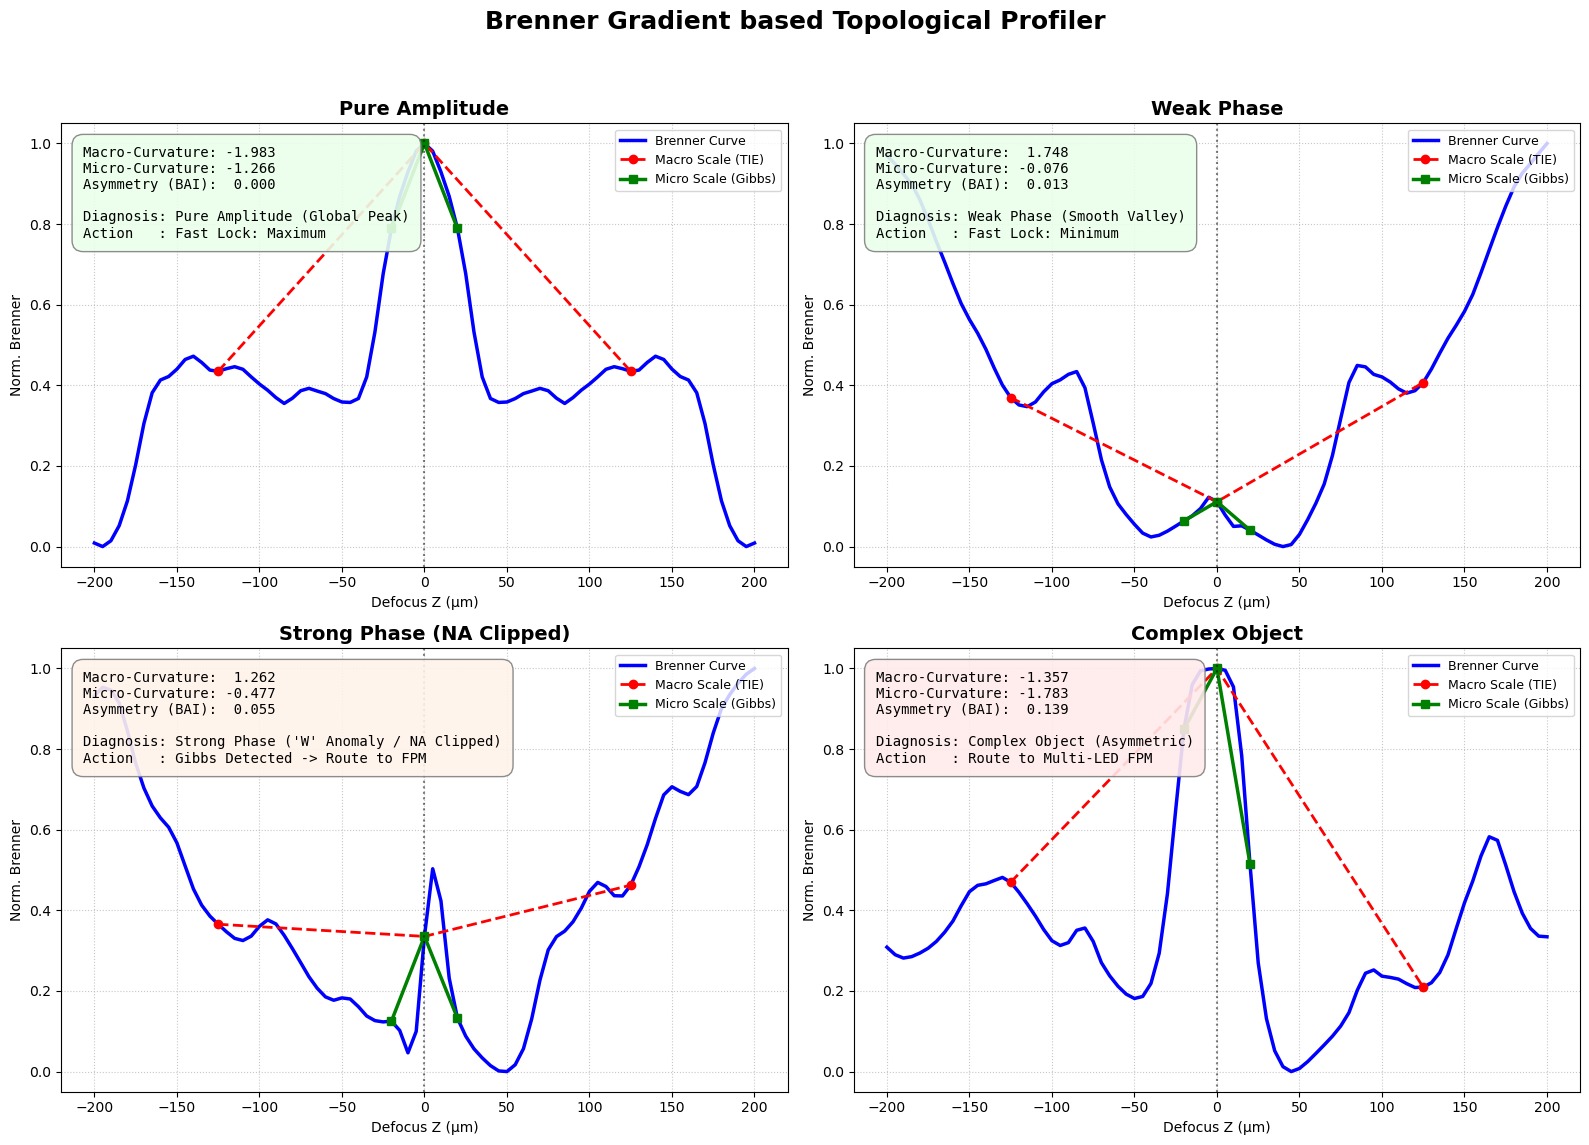

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from scipy.ndimage import gaussian_filter

# ====================================================================
# 1. The Multi-Scale Topological Framework
# ====================================================================
from scipy.signal import savgol_filter

class MultiScaleProfiler:
    def __init__(self, z_array, brenner_scores, wavelength=0.532e-3, NA=0.1):
        self.z = z_array
        
        # 1. Curve Smoothing: Savitzky-Golay filter preserves peak geometry while killing noise
        # window_length=5, polyorder=2 is ideal for Brenner topologies
        smoothed_scores = savgol_filter(brenner_scores, window_length=5, polyorder=2)
        
        # Normalize to [0, 1]
        self.b = (smoothed_scores - np.min(smoothed_scores)) / (np.max(smoothed_scores) - np.min(smoothed_scores) + 1e-8)
        self.c_idx = len(self.z) // 2
        
        # Calculate dynamic indices based on Depth of Field (DoF = lambda / NA^2)
        self.dof = wavelength / (NA**2)
        z_step_size = np.abs(self.z[1] - self.z[0])
        
        # Calculate ideal steps, but CLAMP them so they never exceed the array boundaries
        ideal_micro = max(1, int(np.round(self.dof / z_step_size)))
        ideal_macro = max(5, int(np.round((self.dof * 5) / z_step_size)))
        
        self.micro_steps = min(self.c_idx, ideal_micro)
        self.macro_steps = min(self.c_idx, ideal_macro)

    def analyze(self):
        # 1. Asymmetry Index (BAI)
        left_area = np.sum(self.b[:self.c_idx])
        right_area = np.sum(self.b[self.c_idx+1:])
        bai = np.abs(left_area - right_area) / (left_area + right_area + 1e-8)
        
        # 2. Micro-Curvature (Gibbs Detection)
        b_micro_left = self.b[self.c_idx - self.micro_steps]
        b_micro_right = self.b[self.c_idx + self.micro_steps]
        c_micro = (b_micro_left + b_micro_right - 2 * self.b[self.c_idx])
        
        # 3. Macro-Curvature (TIE Physics)
        b_macro_left = self.b[self.c_idx - self.macro_steps]
        b_macro_right = self.b[self.c_idx + self.macro_steps]
        c_macro = (b_macro_left + b_macro_right - 2 * self.b[self.c_idx])
        
        # --- The Optimized Tolerance Matrix ---
        # tau_micro defines the severity limit for acceptable residual ringing
        tau_micro = -0.25 
        # tau_bai handles experimental noise in asymmetry
        tau_bai = 0.08    
        
        if bai > tau_bai:
            obj_class = "Complex Object (Asymmetric)"
            action = "Route to Multi-LED FPM"
            color = "#ffeaea" # Light Red
            
        elif c_macro < 0 and c_micro < tau_micro:
            obj_class = "Pure Amplitude (Global Peak)"
            action = "Fast Lock: Maximum"
            color = "#eaffea" # Light Green
            
        elif c_macro > 0 and c_micro >= tau_micro:
            # Captures true weak phase even if a microscopic dimple exists (c_micro >= -0.25)
            obj_class = "Weak Phase (Smooth Valley)"
            action = "Fast Lock: Minimum"
            color = "#eaffea"
            
        elif c_macro > 0 and c_micro < tau_micro:
            obj_class = "Strong Phase ('W' Anomaly / NA Clipped)"
            action = "Gibbs Detected -> Route to FPM"
            color = "#fff3ea" # Light Orange
            
        else:
            obj_class = "Ambiguous Topology"
            action = "Route to Multi-LED FPM"
            color = "#eeeeee"
            
        return c_micro, c_macro, bai, obj_class, action, color


    

def calculate_brenner(image):
    img_norm = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-8)
    return np.sum((img_norm[2:, :] - img_norm[:-2, :])**2) + np.sum((img_norm[:, 2:] - img_norm[:, :-2])**2)

# ====================================================================
# 2. Optical Forward Model & Simulation
# ====================================================================
def run_foolproof_simulation():
    print("Initializing Multi-Scale Topology Simulation...")
    
    # Physics Setup (in mm)
    wl = 0.532e-3  
    NA = 0.1           
    mag = 2.0              
    dx = (2.5e-3) / mag 
    N_hr, N_lr = 256, 64
    
    # Generate Objects
    img_amp = transform.resize(data.camera(), (N_hr, N_hr), anti_aliasing=True)
    img_amp = img_amp / np.max(img_amp)
    img_phase = transform.resize(data.moon(), (N_hr, N_hr), anti_aliasing=True)
    img_phase_smooth = gaussian_filter(img_phase, sigma=4)
    img_phase_smooth = img_phase_smooth / np.max(img_phase_smooth)

    objects = {
        "Pure Amplitude": img_amp * np.exp(1j * np.zeros_like(img_amp)),
        "Weak Phase": np.ones_like(img_amp) * np.exp(1j * (img_phase_smooth * 0.2)),
        "Strong Phase (NA Clipped)": np.ones_like(img_amp) * np.exp(1j * (img_phase * 3.0)),
        "Complex Object": img_amp * np.exp(1j * (img_phase_smooth * 1.5))
    }

    # Optics Arrays
    fx = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx))
    FX, FY = np.meshgrid(fx, fx)
    pupil = (np.sqrt(FX**2 + FY**2) <= NA / wl).astype(float)
    kz = 2 * np.pi * np.sqrt(np.maximum((1/wl)**2 - FX**2 - FY**2, 0))
    
    cy, cx = N_hr//2, N_hr//2
    ys, ye, xs, xe = cy - N_lr//2, cy + N_lr//2, cx - N_lr//2, cx + N_lr//2
    z_array = np.linspace(-0.200, 0.200, 81)

    # Run Z-Sweep
    results = {}
    for name, obj in objects.items():
        O_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj)))
        scores = []
        for z in z_array:
            E_fourier = O_fourier[ys:ye, xs:xe] * pupil * np.exp(1j * (z) * kz)
            E_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_fourier)))
            scores.append(calculate_brenner(np.abs(E_spatial)**2))
            
        profiler = MultiScaleProfiler(z_array, np.array(scores))
        c_micro, c_macro, bai, obj_class, action, color = profiler.analyze()
        results[name] = {"scores": profiler.b, "micro": c_micro, "macro": c_macro, 
                         "bai": bai, "class": obj_class, "action": action, "color": color}

    # ====================================================================
    # 3. Visualization Dashboard
    # ====================================================================
    print("Rendering Dashboard...")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Brenner Gradient based Topological Profiler", fontsize=18, fontweight='bold')
    axes = axes.flatten()
    
    for idx, (name, res) in enumerate(results.items()):
        ax = axes[idx]
        b = res["scores"]
        
        # Plot the main curve
        ax.plot(z_array * 1000, b, color='blue', linewidth=2.5, label='Brenner Curve')
        
        # Highlight Macro-Curvature (TIE Physics)
        ax.plot([z_array[40-25]*1000, z_array[40]*1000, z_array[40+25]*1000], 
                [b[40-25], b[40], b[40+25]], 
                'r--', linewidth=2, marker='o', markersize=6, label='Macro Scale (TIE)')
                
        # Highlight Micro-Curvature (NA Artifacts)
        ax.plot([z_array[40-4]*1000, z_array[40]*1000, z_array[40+4]*1000], 
                [b[40-4], b[40], b[40+4]], 
                'g-', linewidth=2.5, marker='s', markersize=6, label='Micro Scale (Gibbs)')
                
        ax.axvline(0, color='k', linestyle=':', alpha=0.5)
        ax.set_title(name, fontsize=14, fontweight='bold')
        ax.set_xlabel("Defocus Z (µm)")
        ax.set_ylabel("Norm. Brenner")
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='upper right', fontsize=9)
        
        # Information Box
        textstr = (f"Macro-Curvature: {res['macro']:>6.3f}\n"
                   f"Micro-Curvature: {res['micro']:>6.3f}\n"
                   f"Asymmetry (BAI): {res['bai']:>6.3f}\n\n"
                   f"Diagnosis: {res['class']}\n"
                   f"Action   : {res['action']}")
                   
        props = dict(boxstyle='round,pad=0.8', facecolor=res['color'], alpha=0.9, edgecolor='gray')
        ax.text(0.03, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', family='monospace', bbox=props)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    run_foolproof_simulation()